# 3.18_Pointing--NIR_Focal_Plane_Mapping

### Imports

In [1]:
''' Make sure you have pandorasim installed and updated '''
# pandorasim, Version: 1.0.10
# pandorasat, Version: 0.5.22

import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) # this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
from pandorasim import plot_nirda_integrations
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, VIS_ra_shape, VIS_dec_shape, NIR_ra_shape, NIR_dec_shape, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR 


/Users/lindseywiser/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
''' Define a PandoraSat object for calling constants '''
p = ps.PandoraSat()

## Define Array Location Function

In [3]:
''' Function defining the pattern of the target location on the array '''
### This function returns a location to point the telescope [in degrees] given an observation id number.
# We will update this function to adjust the pattern based on input from the stakeholders.
# We currently assume that the "home" location is with our target in the center of the NIR array. 
# (ra, dec)=(10,10)deg is only a default for visualization in the next cell.
###

### Set the number of observations here
num_observations = 10 

def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
    ra_home = ra_home
    dec_home = dec_home
    NIR_shape_deg = NIR_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    
    ### center 
    if obsid_num == 0 or obsid_num == 5: location = (ra_home, dec_home)
    
    ### inner ring 
    offset1 = NIR_shape_deg *0.2  ### 20% movement
    if obsid_num == 1 or obsid_num == 6: location = (ra_home-offset1, dec_home)
    if obsid_num == 2 or obsid_num == 7: location = (ra_home, dec_home+offset1)
    if obsid_num == 3 or obsid_num == 8: location = (ra_home+offset1, dec_home)
    if obsid_num == 4 or obsid_num == 9: location = (ra_home, dec_home-offset1)
    
    new_ra = location[0]
    new_dec = location[1]
    return (new_ra, new_dec)

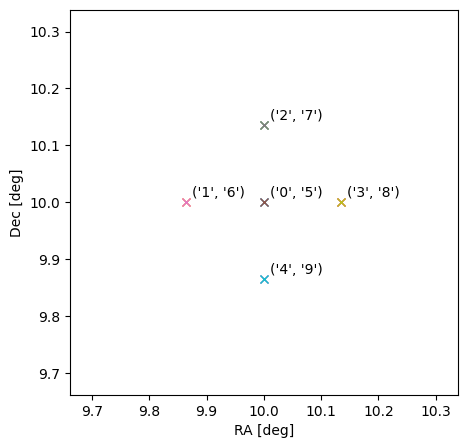

In [4]:
''' Plot the array location pattern on the VISDA array '''
### This is for visualizing the pattern, only. (10,10)deg is a default central location. See function above. 

plt.figure(figsize=(5, 5))
ax = plt.subplot()

for i in range(num_observations):
    loc = array_location(i) ### call the array_location() function above
    ax.plot(loc[0].value,loc[1].value, 'x')
    if i<5:
        ax.annotate((str(i),str(i+5)), (loc[0].value+0.01,loc[1].value+0.01))

plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

NIR_shape_deg = NIR_ra_shape.to(u.degree) ### set plot limits to the shape of VISDA
plt.xlim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))
plt.ylim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))

plt.show()

## Data Volume

10 observations in 2 parts with 5 observations each. Simultaneous VIS and NIR.
- Part 1: smaller NIR subarray for faster readout time and possible time variability measurements.
- Part 2: larger NIR subarray for larger map, but slower readout. 10 VIS frames per integration to match the NIR time as best we can.

In [5]:
''' Constants for this commissioning task '''
num_observations_p1   = 5
num_observations_p2   = 5

regions_VIS           = 2
VIS_xpix              = 200
VIS_ypix              = 200
bits_per_int_VIS      = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS

num_int_NIR           = 25

### VIS Observations

In [6]:
##### VIS Observation - Part 1 #####
frames_per_int_VIS1     = 1
num_int_VIS1            = 1050
int_and_reset_time_VIS1 = frame_time_VIS * frames_per_int_VIS1
bits_per_sec_VIS1       = bits_per_int_VIS / int_and_reset_time_VIS1
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS1
bits_per_sec_comp_VIS1  = bits_per_sec_VIS1 / compression_fractor_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS1 * test_time_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations, Part 1:', Gbits_test_packet_VIS1*num_observations_p1, 'Gbits')

##### VIS Observation - Part 2 #####
frames_per_int_VIS2     = 10
num_int_VIS2            = 934
int_and_reset_time_VIS2 = frame_time_VIS * frames_per_int_VIS2
bits_per_sec_VIS2       = bits_per_int_VIS / int_and_reset_time_VIS2
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS2
bits_per_sec_comp_VIS2  = bits_per_sec_VIS2 / compression_fractor_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS2 * test_time_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('VIS Observations, Part 2:', Gbits_test_packet_VIS2 * num_observations_p2, 'Gbits')

VIS Observations, Part 1: 6.160000000000001 Gbits
VIS Observations, Part 2: 5.479466666666667 Gbits


### NIR Observations

In [7]:
##### NIR Observation - Part 1 #####
NIR_xpix_NIR1              = 84
NIR_ypix_NIR1              = 400
stored_frames_per_int_NIR1 = 24
frames_per_int_NIR1        = 24 
frame_time_NIR1            = NIR_xpix_NIR1 * NIR_ypix_NIR1 * 0.00001 #sec
int_and_reset_time_NIR1    = frame_time_NIR1 * (frames_per_int_NIR1+1)
bits_per_int_NIR1          = NIR_xpix_NIR1 * NIR_ypix_NIR1 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR1
test_time_NIR1             = num_int_NIR * int_and_reset_time_NIR1
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Part 1:', Gbits_test_packet_NIR1 * num_observations_p1, 'Gbits')

##### NIR Observation - Part 2 #####
NIR_xpix_NIR2              = 516
NIR_ypix_NIR2              = 2084
stored_frames_per_int_NIR2 = 6
frames_per_int_NIR2        = 6 
frame_time_NIR2            = NIR_xpix_NIR2 * NIR_ypix_NIR2 * 0.00001 #sec
int_and_reset_time_NIR2    = frame_time_NIR2 * (frames_per_int_NIR2+1)
bits_per_int_NIR2          = NIR_xpix_NIR2 * NIR_ypix_NIR2 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR2
test_time_NIR2             = num_int_NIR * int_and_reset_time_NIR2
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Part 2:', Gbits_test_packet_NIR2 * num_observations_p2, 'Gbits')

NIR Observations, Part 1: 1.1088 Gbits
NIR Observations, Part 2: 8.871588 Gbits


### Total Data Volume

In [8]:
num_observations_total = num_observations_p1 + num_observations_p2 # simultaneous vis and nir
Gbits_total = num_observations_p1*(Gbits_test_packet_VIS1+Gbits_test_packet_NIR1) + num_observations_p2*(Gbits_test_packet_VIS2+Gbits_test_packet_NIR2)
downlinks_total = num_observations_p1*(downlinks_VIS1+downlinks_NIR1) + num_observations_p2*(downlinks_VIS2+downlinks_NIR2)
test_time_total = num_observations_p1*max([test_time_VIS1, test_time_NIR1]) + num_observations_p2*max([test_time_VIS2, test_time_NIR2])

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 2.9053500000000003 hours
Volume, total: 21.61985466666667 Gbits
Downlinks, total: 9.008272777777778


In [9]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'xpix': VIS_xpix, 'ypix': VIS_ypix, 'frames_per_int': frames_per_int_VIS1, 'num_int': num_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'xpix': VIS_xpix, 'ypix': VIS_ypix, 'frames_per_int': frames_per_int_VIS2, 'num_int': num_int_VIS2},
    'NIR1': {'test_time': test_time_NIR1, 'xpix': NIR_xpix_NIR1, 'ypix': NIR_ypix_NIR1, 'frames_per_int': frames_per_int_NIR1, 'num_int': num_int_NIR},
    'NIR2': {'test_time': test_time_NIR2, 'xpix': NIR_xpix_NIR2, 'ypix': NIR_ypix_NIR1, 'frames_per_int': frames_per_int_NIR2, 'num_int': num_int_NIR}
}

## The rest of this notebook should be run for each of the 10 observations. Select an observation number

In [10]:
observation_number = 0  ### possible numbers are 0-9

if observation_number < 5: 
    vis='VIS1'
    nir='NIR1'
if 4 < observation_number < 10: 
    vis='VIS2'
    nir='NIR2'

## Define Target 

For now, we select an arbitrary primary target. A list of possible targets is being made (check with Aisha Iyer or Lindsey Wiser for updates).

In [11]:
### Posible Targets:
# ...
# ...
# ...
# ...

In [12]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "GJ 3470"
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
simVIS = VisibleSim(ROI_size=(obs_dict[vis]['xpix'], obs_dict[vis]['ypix']), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

Output()

Output()

In [13]:
''' Define the center of our observation based on target location and observation number '''
location = array_location(observation_number, c.ra, c.dec)
ra0        = location[0] 
dec0       = location[1] 
theta0     = 0*u.deg


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
simVIS.point(ra0, dec0, theta0)
simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

Output()

Output()

Output()

Output()

Output()

2025-02-19 15:26:23 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

Output()

In [14]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = simVIS.source_catalog
#print(cat)

## Generate Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

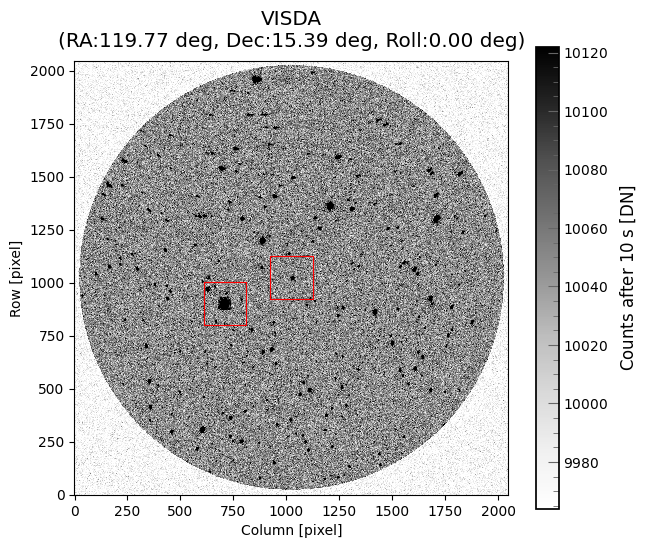

In [16]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [22]:
''' Save ROI locations in sky coordinates for later '''
VISroi0_coord = simVIS.pixel_to_world(simVIS.ROI_corners[0][0], simVIS.ROI_corners[0][1])
VISroi1_coord = simVIS.pixel_to_world(simVIS.ROI_corners[1][0], simVIS.ROI_corners[1][1])

In [23]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

data = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 18/18 [00:01<00:00,  9.17it/s]


(2, 1050, 200, 200)

array([[<Axes: ylabel='Row\n[subarray pixel]'>, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

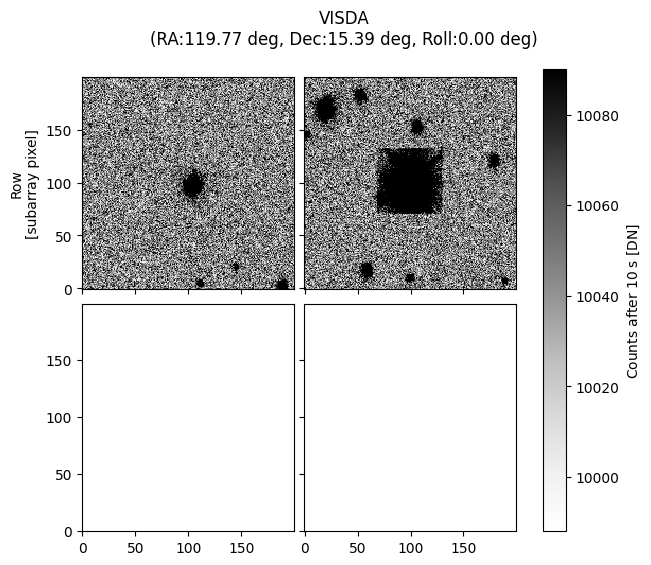

In [24]:
''' Plot our ROIs (regions of interest). ''' 
simVIS.show_ROI()

## NIR Observation

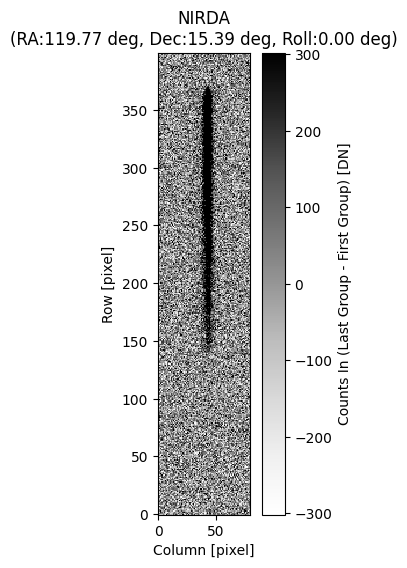

In [25]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [26]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted

# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (obs_dict[nir]['xpix'], obs_dict[nir]['ypix']) ### THIS CANNOT YET BE SPECIFIED IN sim.observe()

data = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████| 9/9 [01:03<00:00,  7.06s/it]


(25, 2, 400, 80)

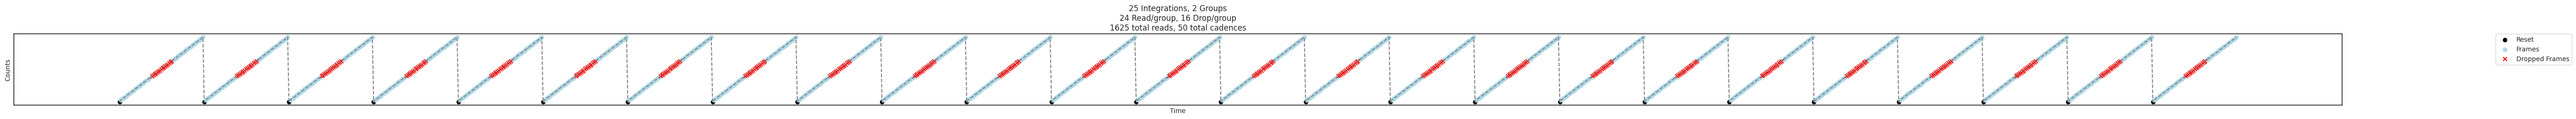

In [31]:
''' Plot the NIRDA integration scheme '''
plot_nirda_integrations(SC_Resets1=1,
    SC_Resets2=1,
    SC_DropFrames1=0,
    SC_DropFrames2=16,
    SC_DropFrames3=0,
    SC_ReadFrames=obs_dict[nir]['frames_per_int'],
    SC_Groups=2,
    SC_Integrations=obs_dict[nir]['num_int']);

## Save the simulated observation

In [32]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time)
hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.18_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.18_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|█████████████████| 11/11 [01:05<00:00,  5.95s/it]


In [33]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.18_VISrois_GJ3470_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (400, 400, 1050)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 2C   [D, K]   
None


## Data Products

### RD-B2: table that provides mapping between sky and detector positions to quantify field distortions

### RD-B3: table that provides mapping between sky and detector positions to quantify boresign alignment

## Generate SOC File

In [35]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 

variables = {
    'visit_id': '0318', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0,
    'DEC': dec0, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': ra0, 
    'NIR_ROI_StartY': dec0, 
    'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
    'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': obs_dict[vis]['frames_per_int'], 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [obs_dict[vis]['xpix'], obs_dict[vis]['ypix']], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': [VISroi0_coord[0], VISroi1_coord[0]], ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': [VISroi0_coord[1], VISroi1_coord[1]], 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [36]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)